<a href="https://colab.research.google.com/github/dhanush78945-afk/Assignment1-AIML/blob/main/homeprice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
path = kagglehub.dataset_download("muhammadbinimran/housing-price-prediction-data")

100%|██████████| 763k/763k [00:00<00:00, 1.22MB/s]

Extracting files...


In [3]:
import os
import pandas as pd

# List files in the downloaded directory to identify the CSV file
print(os.listdir(path))

# Correct the CSV file name based on the actual file found
csv_file_path = os.path.join(path, 'housing_price_dataset.csv')

# Load the dataset
df = pd.read_csv(csv_file_path)

# Display the first few rows of the DataFrame
display(df.head())

['housing_price_dataset.csv']


,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price
0,2126,4,1,Rural,1969,215355.283618
1,2459,3,2,Rural,1980,195014.221626
2,1860,2,1,Suburb,1970,306891.012076
3,2294,2,1,Urban,1996,206786.787153
4,2130,5,2,Suburb,2001,272436.239065


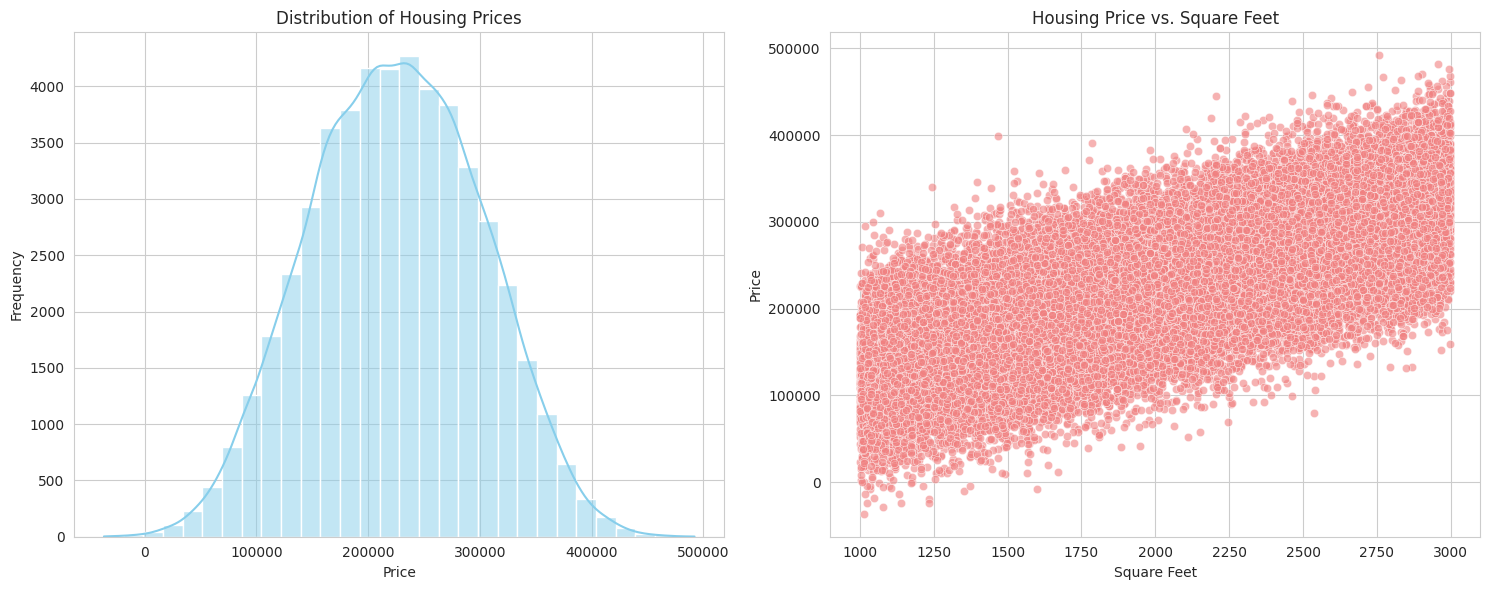

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create a figure with two subplots
plt.figure(figsize=(15, 6))

# Subplot 1: Histogram of Price distribution
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.histplot(df['Price'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Housing Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')

# Subplot 2: Scatter plot of SquareFeet vs Price
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.scatterplot(x='SquareFeet', y='Price', data=df, alpha=0.6, color='lightcoral')
plt.title('Housing Price vs. Square Feet')
plt.xlabel('Square Feet')
plt.ylabel('Price')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

## Data Preprocessing

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify features (X) and target (y)
X = df.drop('Price', axis=1)
y = df['Price']

# Identify categorical and numerical features
categorical_features = ['Neighborhood']
numerical_features = ['SquareFeet', 'Bedrooms', 'Bathrooms', 'YearBuilt']

# Create a column transformer for preprocessing
# One-hot encode categorical features and pass through numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data preprocessing complete. Training and testing sets created.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

Data preprocessing complete. Training and testing sets created.
X_train shape: (40000, 5)
X_test shape: (10000, 5)


## Model Training and Evaluation

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np # Import numpy for square root

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42)
}

# Store results
results = {}

# Train and evaluate each model
for name, model in models.items():
    print(f"\n--- Training {name} ---")

    # Create a pipeline that first preprocesses and then trains the model
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', model)])

    # Train the model
    pipeline.fit(X_train, y_train)

    # Make predictions
    y_pred = pipeline.predict(X_test)

    # Evaluate the model
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse) # Calculate RMSE using numpy.sqrt
    r2 = r2_score(y_test, y_pred)

    results[name] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

    print(f"{name} - MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}")

# Display all results in a DataFrame for easy comparison
results_df = pd.DataFrame(results).T
display(results_df)


--- Training Linear Regression ---
Linear Regression - MAE: 39430.17, MSE: 2436249371.31, RMSE: 49358.38, R2: 0.58

--- Training Decision Tree ---
Decision Tree - MAE: 57715.06, MSE: 5215481912.08, RMSE: 72218.29, R2: 0.09

--- Training Random Forest ---
Random Forest - MAE: 41928.50, MSE: 2760538432.81, RMSE: 52540.83, R2: 0.52


,MAE,MSE,RMSE,R2
Linear Regression,39430.165338,2.436249e+09,49358.376911,0.575563
Decision Tree,57715.060067,5.215482e+09,72218.293473,0.091372
Random Forest,41928.498235,2.760538e+09,52540.826343,0.519066


## Logistic Regression (Classification)

Logistic Regression is a classification algorithm, not directly suitable for continuous target variables like 'Price'. If you want to use Logistic Regression, we would need to convert the 'Price' into a categorical variable (e.g., 'High Price', 'Medium Price', 'Low Price').

Let me know if you would like to proceed with a classification task by discretizing the 'Price' variable for Logistic Regression.